# Анализ метрик проведенных экспериментов

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import os

In [2]:
def plot_confusion_matrix(cm, labels, title="", figsize=(7, 6), normalize=True):
    cm = np.asarray(cm, dtype=float)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, where=row_sums != 0)

    if normalize:
        data = cm_norm
        annot = np.array([
            [f"{int(count)}\n{share:.2f}" for count, share in zip(row, nrow)]
            for row, nrow in zip(cm, cm_norm)
        ])
        fmt = "s"
        cbar_label = "Доля (по строке)"
        vmin, vmax = 0.0, 1.0
    else:
        data = cm
        annot = True
        fmt = ".0f"
        cbar_label = "Количество"
        vmin, vmax = None, None

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        data,
        annot=annot,
        fmt=fmt,
        xticklabels=labels,
        yticklabels=labels,
        cmap="Blues",
        square=True,
        vmin=vmin,
        vmax=vmax,
        cbar_kws={"label": cbar_label},
        ax=ax,
    )
    ax.set_xlabel("Предсказанный класс")
    ax.set_ylabel("Истинный класс")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [3]:
def get_experiment_results(run_name: str):
    results_path = Path(f"../logs/{run_name}")
    print(f'Experiment: {run_name}')
    metrics = pd.read_csv(results_path / 'metrics.csv')
    with open(results_path / 'summary.json') as f:
        summary = json.load(f)
    output_df = {}
    if 'train' in summary['results'].keys():
        output_df['train'] = [
            summary['results']['train']['loss'],
            summary['results']['train']['patch']['accuracy'],
            summary['results']['train']['patch']['precision'],
            summary['results']['train']['patch']['recall'],
            summary['results']['train']['patch']['f1']
        ]
    output_df['val'] = [
        summary['results']['val']['loss'],
        summary['results']['val']['patch']['accuracy'],
        summary['results']['val']['patch']['precision'],
        summary['results']['val']['patch']['recall'],
        summary['results']['val']['patch']['f1']
    ]
    output_df['test'] = [
        summary['results']['test']['loss'],
        summary['results']['test']['patch']['accuracy'],
        summary['results']['test']['patch']['precision'],
        summary['results']['test']['patch']['recall'],
        summary['results']['test']['patch']['f1']
    ]
    output_df = pd.DataFrame(output_df, index=['loss', 'accuracy', 'precision', 'recall', 'f1'])
    print(output_df)

    if 'train_patch_accuracy' in metrics.columns:
        plt.title('Accuracy')
        sns.lineplot(x='epoch', y='train_patch_accuracy', data=metrics, label='train')
        sns.lineplot(x='epoch', y='val_patch_accuracy', data=metrics, label='val')
        plt.ylabel('accuracy')
        plt.show()

        plt.title('F1')
        sns.lineplot(x='epoch', y='train_patch_f1', data=metrics, label='train')
        sns.lineplot(x='epoch', y='val_patch_f1', data=metrics, label='val')
        plt.ylabel('F1')
        plt.show()

    elif 'train_eval_patch_accuracy' in metrics.columns:
        plt.title('Accuracy')
        sns.lineplot(x='epoch', y='train_eval_patch_accuracy', data=metrics, label='train')
        sns.lineplot(x='epoch', y='val_patch_accuracy', data=metrics, label='val')
        plt.ylabel('accuracy')
        plt.show()

        plt.title('F1')
        sns.lineplot(x='epoch', y='train_eval_patch_f1', data=metrics, label='train')
        sns.lineplot(x='epoch', y='val_patch_f1', data=metrics, label='val')
        plt.ylabel('F1')
        plt.show()

    else:
        plt.title('Accuracy')
        sns.lineplot(x='epoch', y='val_patch_accuracy', data=metrics, label='val')
        plt.ylabel('accuracy')
        plt.show()

        plt.title('F1')
        sns.lineplot(x='epoch', y='val_patch_f1', data=metrics, label='val')
        plt.ylabel('F1')
        plt.show()

    class_names = summary['class_names']
    plot_confusion_matrix(
        summary['results']['test']['patch']['confusion_matrix'],
        labels=class_names,
        title=f"{run_name}",
    )

## Общие метрики

In [6]:
# for rname in os.listdir('../logs'):
#     try:
#         get_experiment_results(rname)
#     except Exception as e:
#         pass

## Accuracy и F1 по экспериментам

In [4]:
runs = []
accs = []
f1s = []
for rname in os.listdir('../logs'):
    if 'summary.json' in os.listdir(f'../logs/{rname}'):
        runs.append(rname)
        with open(Path(f'../logs/{rname}') / 'summary.json') as f:
            summary = json.load(f)
        accs.append(summary['results']['test']['patch']['accuracy'])
        f1s.append(summary['results']['test']['patch']['f1'])

pd.DataFrame({
    'Test accuracy': accs,
    'Test F1': f1s
}, index=runs).sort_values(by='Test accuracy', ascending=False)

,Test accuracy,Test F1
abl_p3_noise01_20260919_234137,0.696823,0.684013
abl_p3_size256_20260920_122323,0.690091,0.681077
abl_p2_rot90_20260918_212536,0.685900,0.676115
abl_p3_size256_noise01_20260920_150343,0.683773,0.676365
abl_p2_sa12_20260919_130929,0.676633,0.665099
abl_overlap_train05_no_blur_20260917_202042,0.673323,0.665560
abl_p2_t8_dist_20260919_041841,0.669903,0.657458
abl_p3_rot90_sa12_20260919_213344,0.668027,0.653956
abl_overlap_train05_20260917_112844,0.666152,0.654164
abl_p1_ls0_20260918_084914,0.664056,0.653289


Experiment: twistnet18_20260921_221818
              train       val      test
loss       0.801886  1.116164  1.229612
accuracy   0.791758  0.649858  0.584841
precision  0.788393  0.627624  0.577735
recall     0.784661  0.628422  0.565210
f1         0.784095  0.626844  0.564733


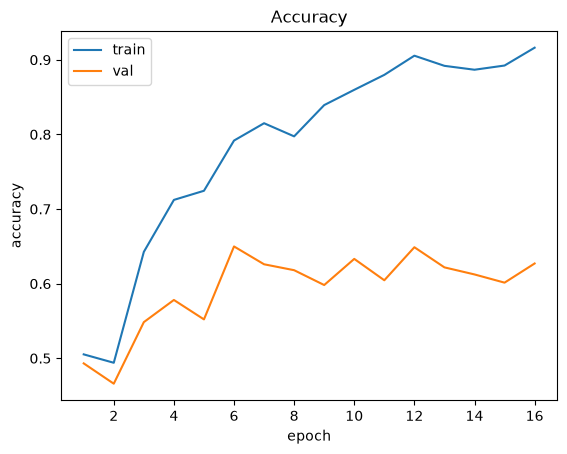

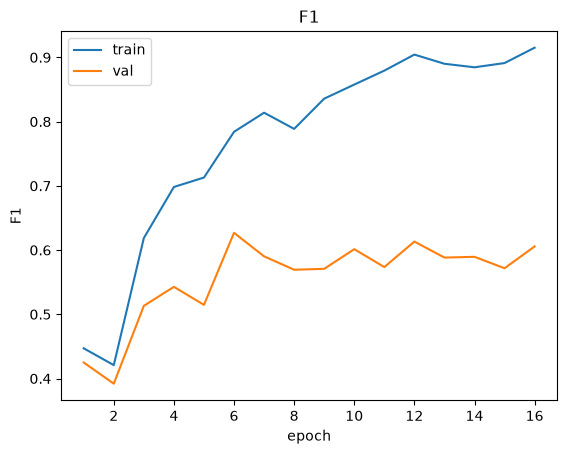

/tmp/ipykernel_68028/3840804484.py:4: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_norm = np.divide(cm, row_sums, where=row_sums != 0)


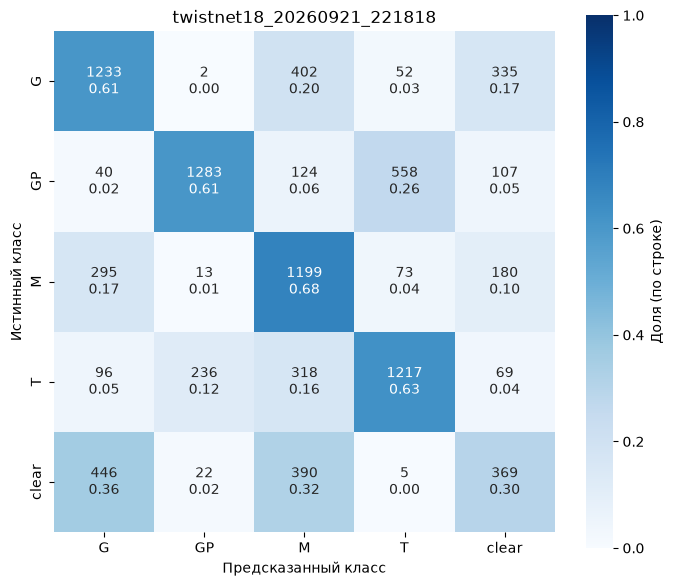

In [9]:
get_experiment_results('twistnet18_20260921_221818')